In [ ]:
from settings import DATA_DIR, ROOT_DIR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import pickle
import re
from collections import defaultdict
import plotly.express as px
import plotly.graph_objects as go

from nteprsm import utils
from importlib import reload
reload(utils)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
/Users/henryqu/Library/Caches/pypoetry/virtualenvs/nteprsm-kiQW9mOZ-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'nteprsm.utils' from '/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py'>

In [53]:
def extract_time_effect(datahandler: "utils.DataHandler", fit: "stan fit object") -> pd.DataFrame:
    """
    Extract and format the time effect from a fitted model object.

    Args:
        datahandler (utils.DataHandler): Data handler containing model data with 'entry_cumcount' and 'adj_day_of_year' columns.
        fit: Fitted model object containing the 'time_effect' variable.

    Returns:
        pd.DataFrame: DataFrame with 'adj_day_of_year' as index and time effects as columns, sorted and formatted.
    """
    cumcount2doy = (
        datahandler.model_data[['entry_cumcount', 'adj_day_of_year']]
        .sort_values(by='entry_cumcount')
        .drop_duplicates(subset='entry_cumcount')
    )
    time_effect = pd.DataFrame(
        fit.stan_variable("time_effect").mean(axis=0),
        columns=cumcount2doy['adj_day_of_year'].values
    )
    time_effect = time_effect.loc[:, ~time_effect.columns.duplicated()]
    time_effect.index = time_effect.index + 1
    time_effect = time_effect.reindex(sorted(time_effect.columns), axis=1).T
    time_effect.index.name = 'adj_day_of_year'
    return time_effect

def extract_plot_effect(datahandler: "utils.DataHandler", fit: "stan fit object") -> pd.DataFrame:
    """
    Extract plot effects from the fitted model.

    Args:
        datahandler (utils.DataHandler): Data handler with model data.
        fit: Fitted model object containing the 'plot_effect' variable.

    Returns:
        pd.DataFrame: DataFrame with mean row, col, and plot_effect for each plot_code.
    """
    plot_data = datahandler.model_data.groupby("plot_code")[["row", "col"]].mean()
    plot_data.reset_index(inplace=True)
    plot_data['plot_effect'] = fit.stan_variable("plot_effect").mean(axis=0)
    # add plot_code 
    entry_data = datahandler.model_data[['entry_code', 'row', 'col']].drop_duplicates()
    plot_data = pd.merge(plot_data, entry_data, on=['row', 'col'], how='left')
    plot_data.drop_duplicates(subset=['row', 'col'], inplace=True)
    return plot_data

def plot_field_layout(
    plot_data: pd.DataFrame,
    trait: str,
    loc: str,
    model: str,
    save_path: str = None
) -> None:
    """
    Plot the field layout as a heatmap of plot effects.

    Args:
        plot_data (pd.DataFrame): DataFrame with 'row', 'col', and 'plot_effect'.
        trait (str): Trait name.
        loc (str): Location identifier.
        model (str): Model name.
        save_path (str, optional): Path to save the plot. Defaults to None.
    """
    heatmap_data = plot_data.pivot(index="row", columns="col", values="plot_effect")
    plt.figure(figsize=(8, 8))
    im = plt.imshow(heatmap_data, aspect='equal', origin='lower', cmap='viridis')
    plt.colorbar(im, label='plot_effect')
    plt.title(f"Plot effects for {trait} at {loc} using {model} model")
    plt.xlabel("col")
    plt.ylabel("row")
    plt.xticks(np.arange(heatmap_data.shape[1]), heatmap_data.columns.astype(int))
    plt.yticks(np.arange(heatmap_data.shape[0]), heatmap_data.index.astype(int))
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

def extract_pred_time_effect(
    fit,
    func: callable = np.mean,
    *args,
    **kwargs
) -> pd.DataFrame:
    """
    Extract and format the predicted time effect from a fitted model object.

    Args:
        fit: Fitted model object containing the 'pred_time_effect' variable.
        func (callable, optional): Function to apply to the predicted time effect (default: np.mean).
        *args: Additional positional arguments for func.
        **kwargs: Additional keyword arguments for func.

    Returns:
        pd.DataFrame: DataFrame with 'adj_day_of_year' as index and predicted time effects as columns, sorted and formatted.
    """
    data = func(fit.stan_variable("pred_time_effect"), axis=0, *args, **kwargs).T
    pred_data = pd.DataFrame(data)
    pred_data.index = 365 * (pred_data.index + 1)/len(pred_data.index)
    pred_data.index.name = 'adj_day_of_year'
    pred_data.columns = pred_data.columns + 1
    return pred_data

In [4]:
output_path = DATA_DIR/"model_output/kb2017"
output_files = glob.glob(str(output_path)+ "/*.pkl")
entry_info = pd.read_csv(DATA_DIR/"data_ingestion/raw_data/kb2017/2017NTEPKBG_ENTRY_INFO.csv")

In [10]:
import json

entry_dict = entry_info.set_index('entry_code')['entry_name'].to_dict()
with open(DATA_DIR / "model_output/entrycode2name.json", "w") as f:
    json.dump(entry_dict, f, indent=2)

In [11]:
# organize the output files by model, location, and trait using custom pattern
pattern = re.compile(r'fit_(\w+)_([a-z]{2}\d)_([\w_]+)\.pkl')
organized_files = defaultdict(lambda: defaultdict(dict))

for f in output_files:
    m = pattern.search(f)
    if m:
        model, loc, trait = m.groups()
        organized_files[loc][model][trait] = f
organized_files

defaultdict(<function __main__.<lambda>()>,
            {'ok1': defaultdict(dict,
                         {'spatial': {'density': '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/fit_spatial_ok1_density.pkl',
                           'rust': '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/fit_spatial_ok1_rust.pkl',
                           'spring_greenup': '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/fit_spatial_ok1_spring_greenup.pkl',
                           'color': '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/fit_spatial_ok1_color.pkl',
                           'texture': '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/fit_spatial_ok1_texture.pkl'},
                          'seasonalit

2025-05-26 23:23:52,486 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:23:52,499 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:23:52,503 - NtepRsm - INFO - Data preprocessing completed.


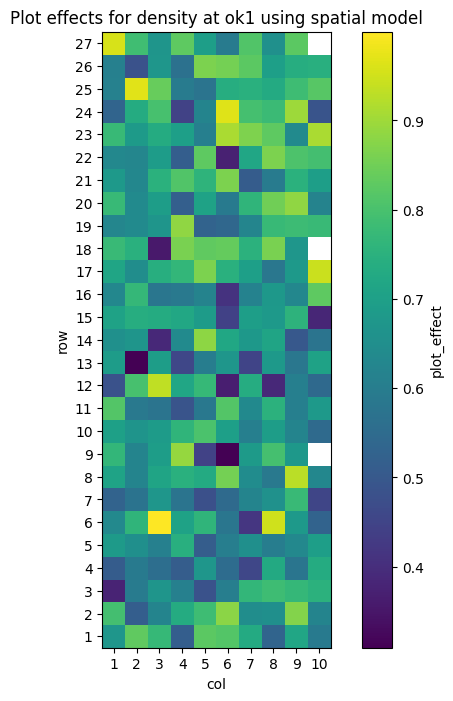

2025-05-26 23:23:52,790 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:23:52,795 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:23:52,797 - NtepRsm - INFO - Data preprocessing completed.


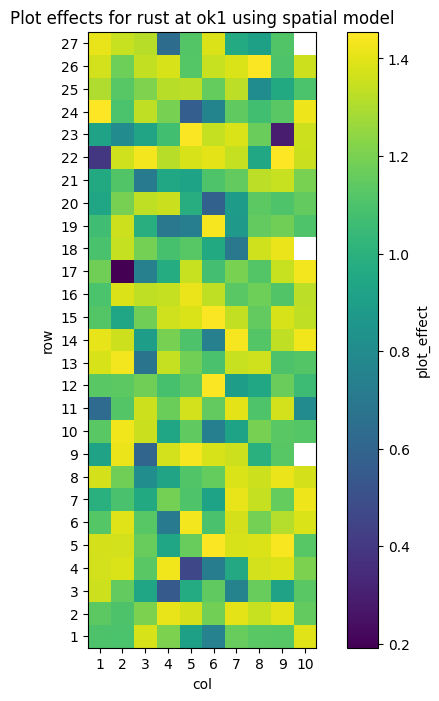

2025-05-26 23:23:53,018 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:23:53,022 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:23:53,024 - NtepRsm - INFO - Data preprocessing completed.


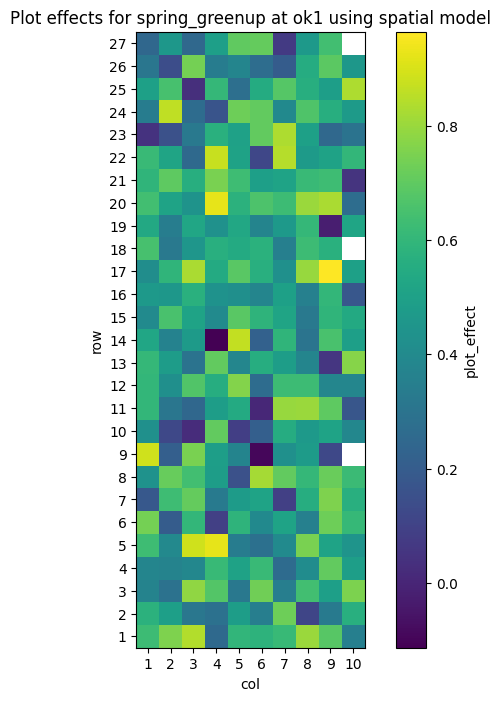

2025-05-26 23:23:53,234 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:23:53,239 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:23:53,241 - NtepRsm - INFO - Data preprocessing completed.


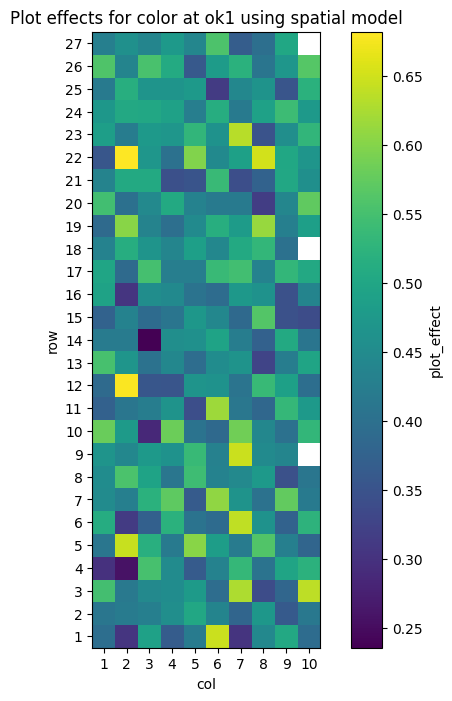

2025-05-26 23:23:53,459 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:23:53,464 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:23:53,467 - NtepRsm - INFO - Data preprocessing completed.


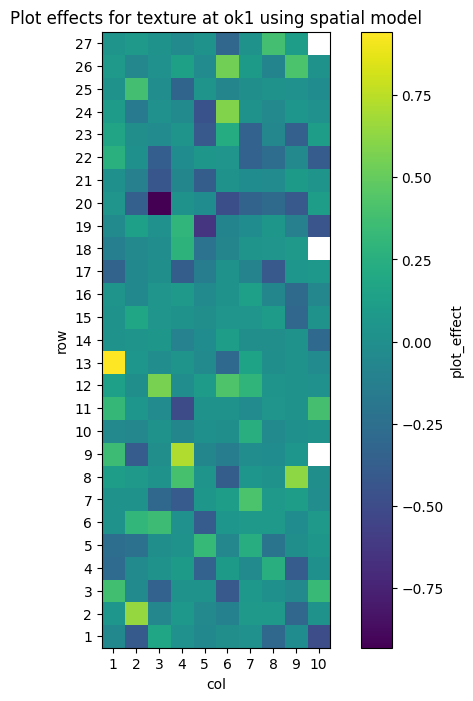

2025-05-26 23:23:53,700 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:23:53,729 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:23:53,736 - NtepRsm - INFO - Data preprocessing completed.


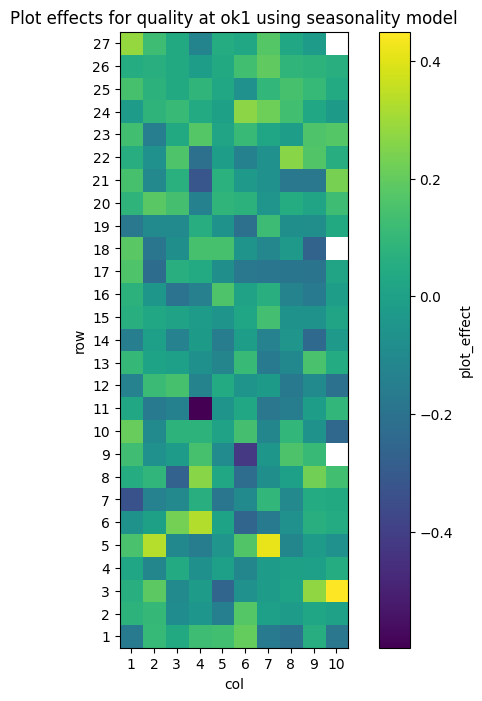

2025-05-26 23:24:03,974 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:03,982 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:03,986 - NtepRsm - INFO - Data preprocessing completed.


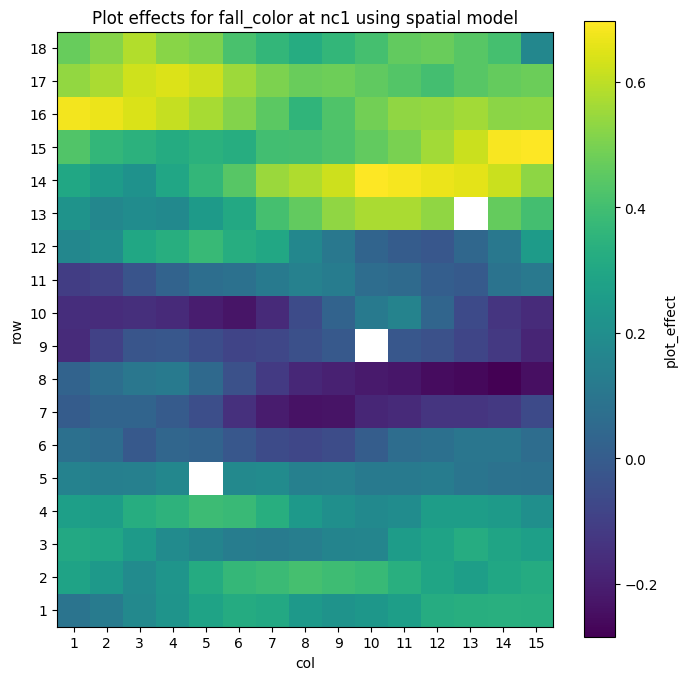

2025-05-26 23:24:04,405 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:04,411 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:04,414 - NtepRsm - INFO - Data preprocessing completed.


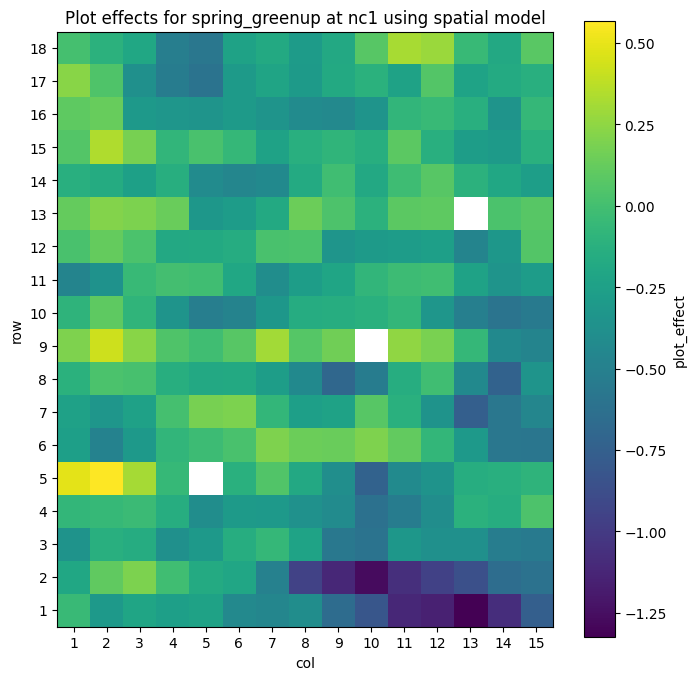

2025-05-26 23:24:04,664 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:04,668 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:269: UserWarning: Column 'plot_code' does not contain continuous codes starting from 1 to 267. Fixing codes using pd.Categorical().codes + 1.
  warnings.warn(
2025-05-26 23:24:04,671 - NtepRsm - INFO - Data preprocessing completed.


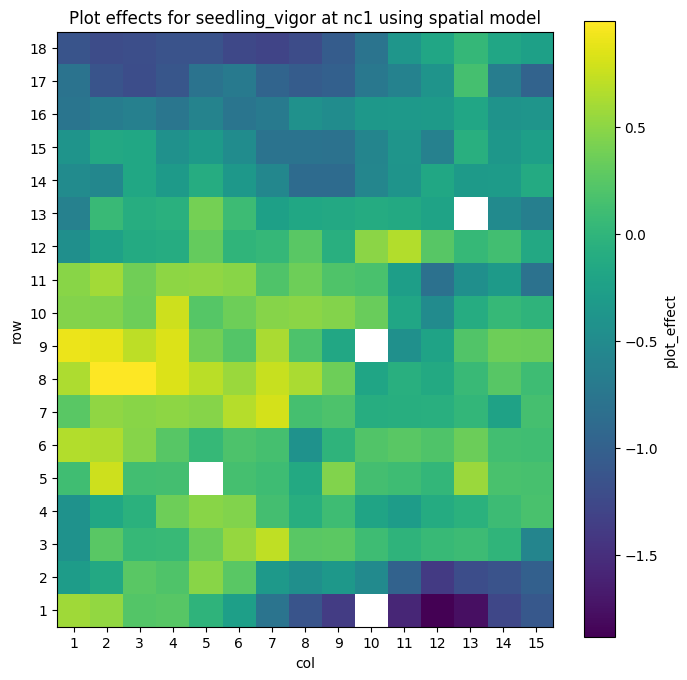

2025-05-26 23:24:04,904 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:04,911 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:04,915 - NtepRsm - INFO - Data preprocessing completed.


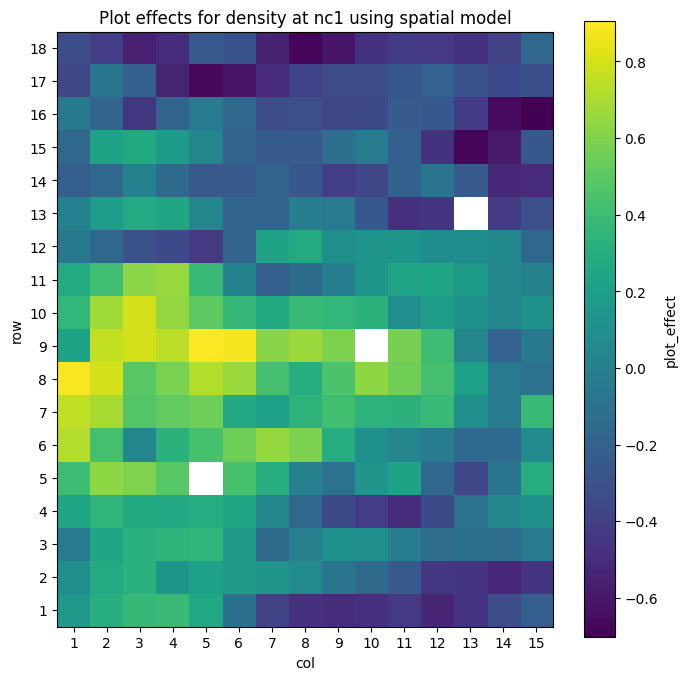

2025-05-26 23:24:05,178 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:05,187 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:05,190 - NtepRsm - INFO - Data preprocessing completed.


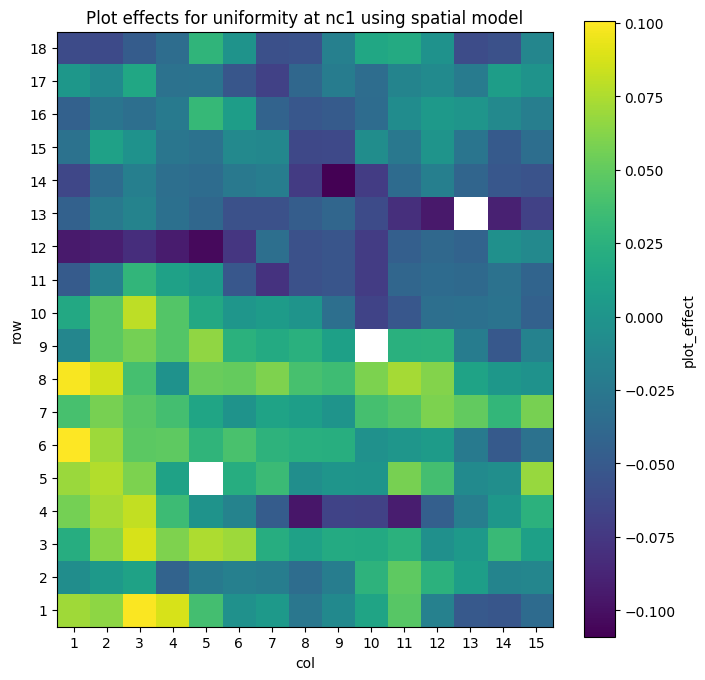

2025-05-26 23:24:05,452 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:05,456 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:05,458 - NtepRsm - INFO - Data preprocessing completed.


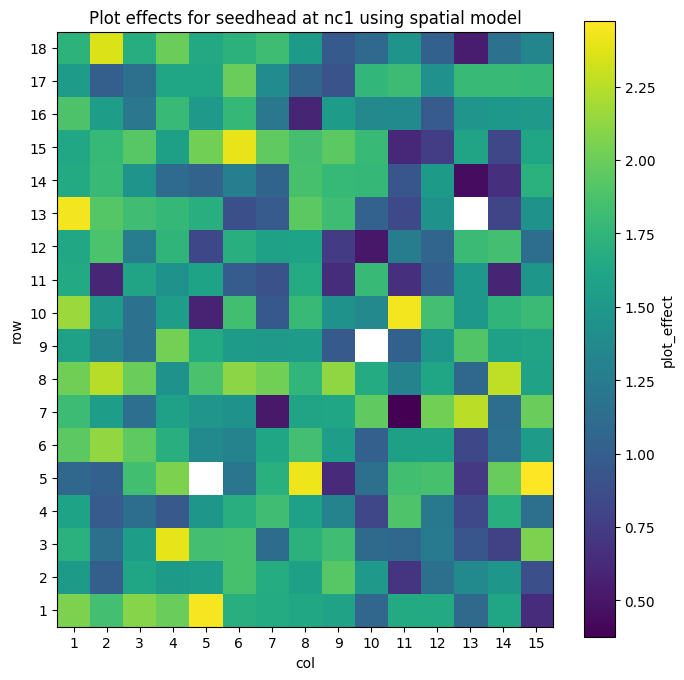

2025-05-26 23:24:05,703 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:05,710 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:05,714 - NtepRsm - INFO - Data preprocessing completed.


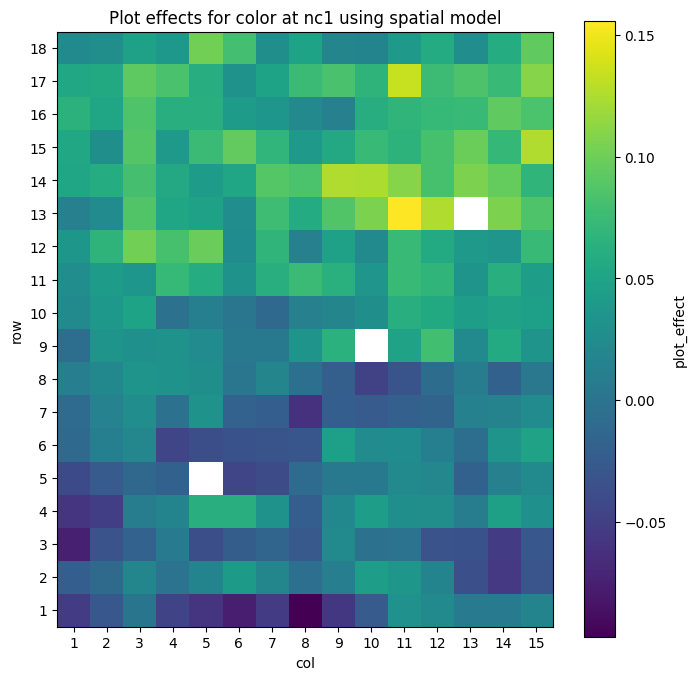

2025-05-26 23:24:05,959 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:05,971 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:05,976 - NtepRsm - INFO - Data preprocessing completed.


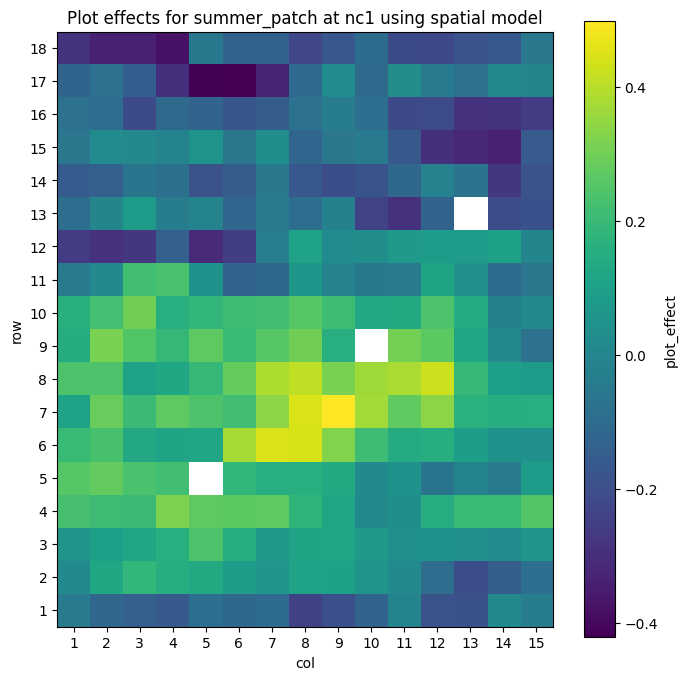

2025-05-26 23:24:06,258 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:06,264 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:06,267 - NtepRsm - INFO - Data preprocessing completed.


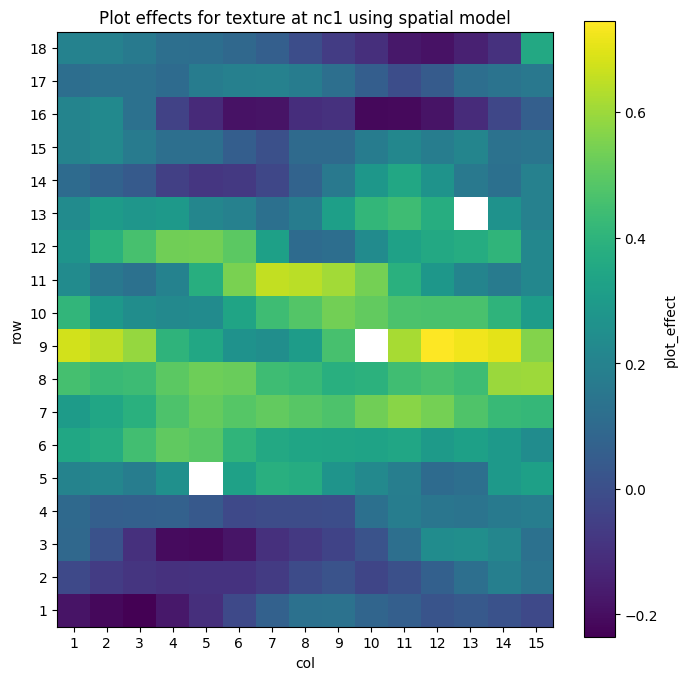

2025-05-26 23:24:06,508 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:06,546 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:06,553 - NtepRsm - INFO - Data preprocessing completed.


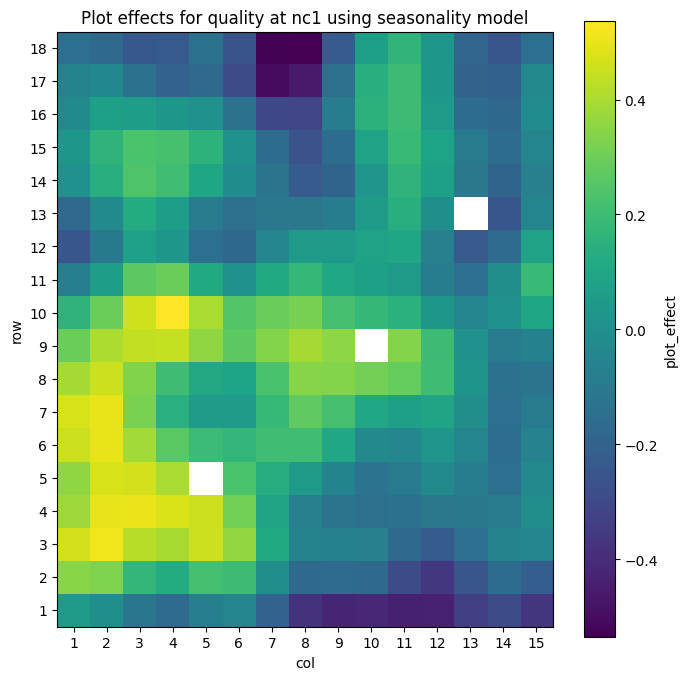

2025-05-26 23:24:16,958 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:16,965 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:16,969 - NtepRsm - INFO - Data preprocessing completed.


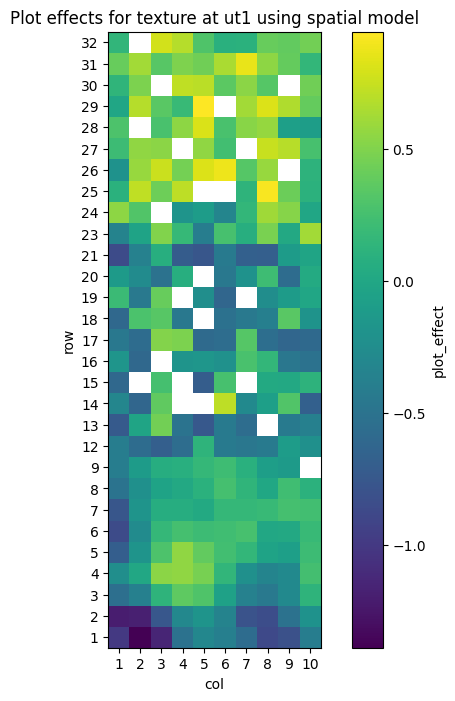

2025-05-26 23:24:17,230 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:17,234 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:17,236 - NtepRsm - INFO - Data preprocessing completed.


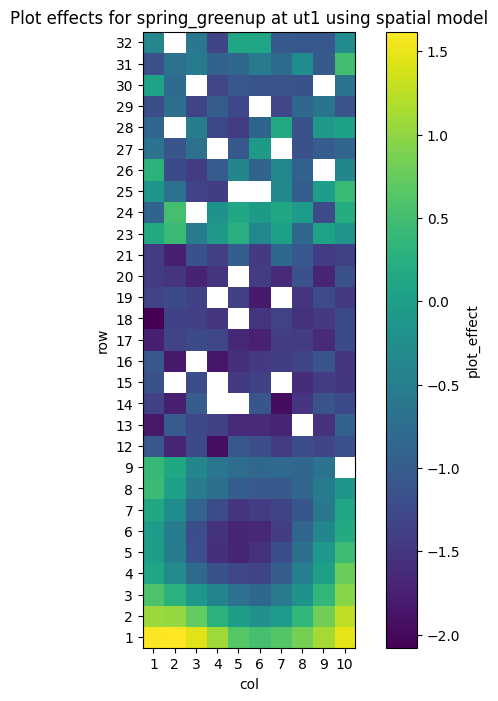

2025-05-26 23:24:17,458 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:17,464 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:17,466 - NtepRsm - INFO - Data preprocessing completed.


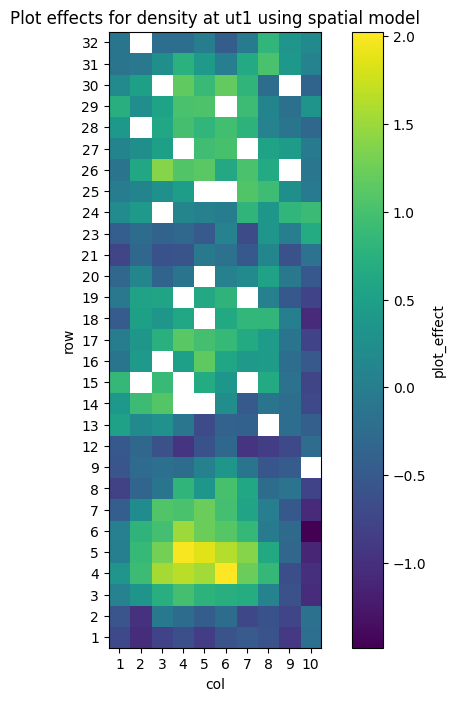

2025-05-26 23:24:17,706 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:17,714 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:17,717 - NtepRsm - INFO - Data preprocessing completed.


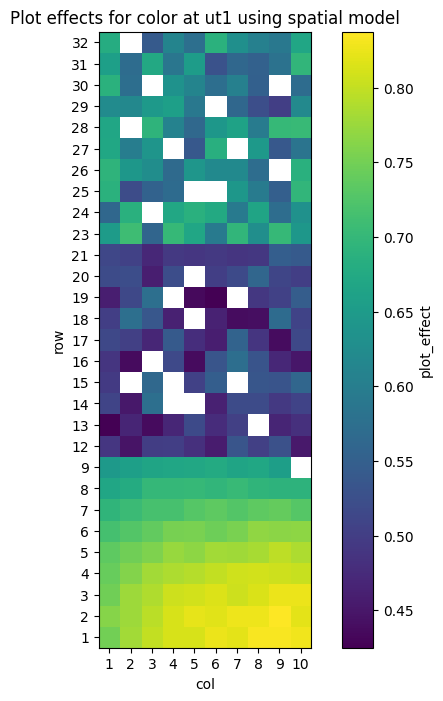

2025-05-26 23:24:17,961 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:17,984 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:17,990 - NtepRsm - INFO - Data preprocessing completed.


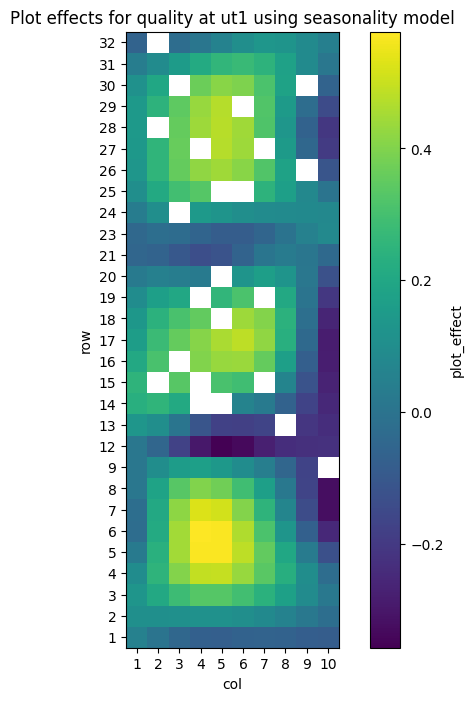

2025-05-26 23:24:24,313 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:24,320 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:24,323 - NtepRsm - INFO - Data preprocessing completed.


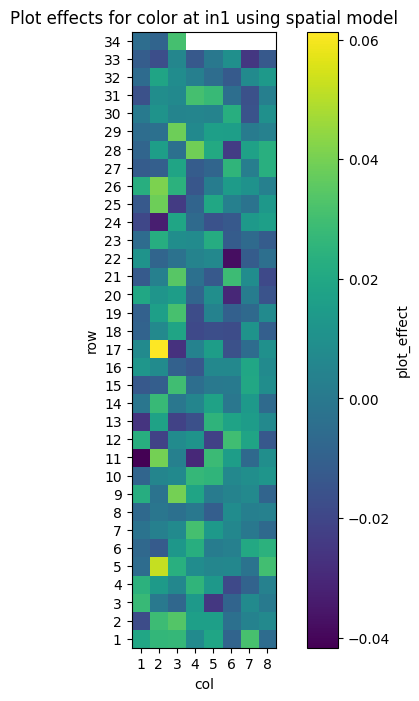

2025-05-26 23:24:24,592 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:24,599 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:24,602 - NtepRsm - INFO - Data preprocessing completed.


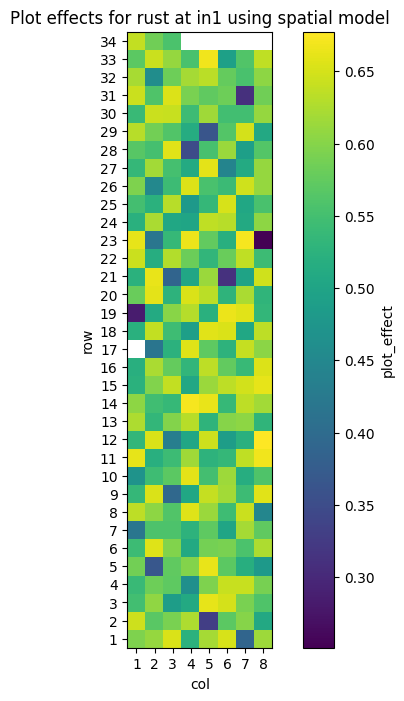

2025-05-26 23:24:24,836 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:24,842 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:24,845 - NtepRsm - INFO - Data preprocessing completed.


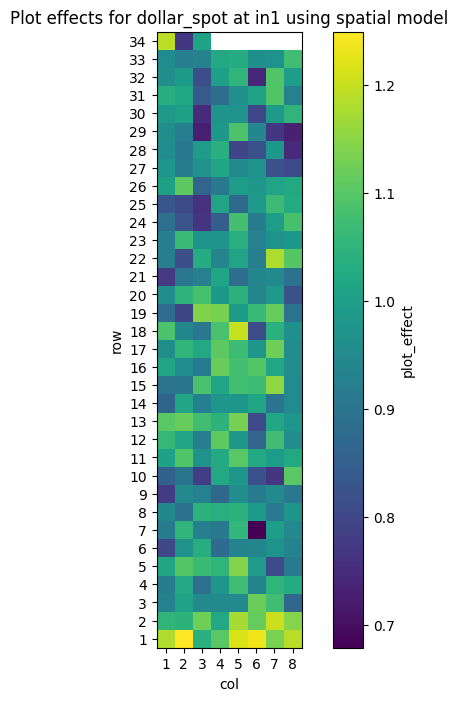

2025-05-26 23:24:25,080 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:25,087 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:25,090 - NtepRsm - INFO - Data preprocessing completed.


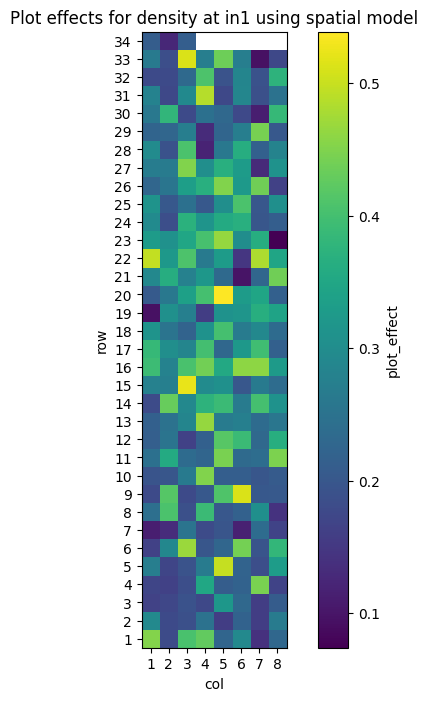

2025-05-26 23:24:25,329 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:25,333 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:269: UserWarning: Column 'plot_code' does not contain continuous codes starting from 1 to 267. Fixing codes using pd.Categorical().codes + 1.
  warnings.warn(
2025-05-26 23:24:25,336 - NtepRsm - INFO - Data preprocessing completed.


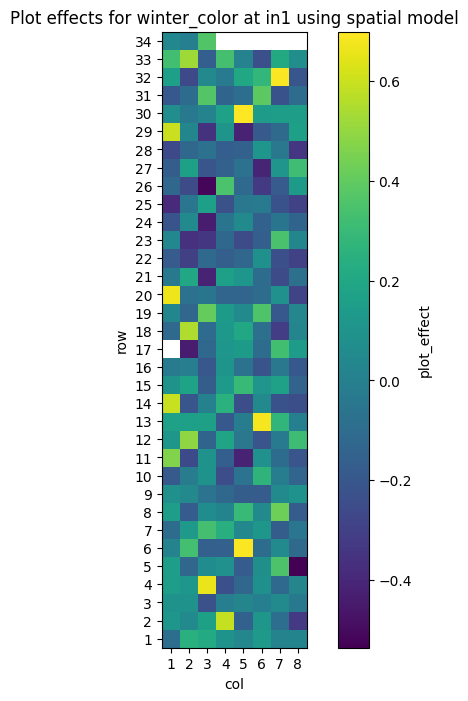

2025-05-26 23:24:25,561 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:25,565 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:269: UserWarning: Column 'plot_code' does not contain continuous codes starting from 1 to 267. Fixing codes using pd.Categorical().codes + 1.
  warnings.warn(
2025-05-26 23:24:25,567 - NtepRsm - INFO - Data preprocessing completed.


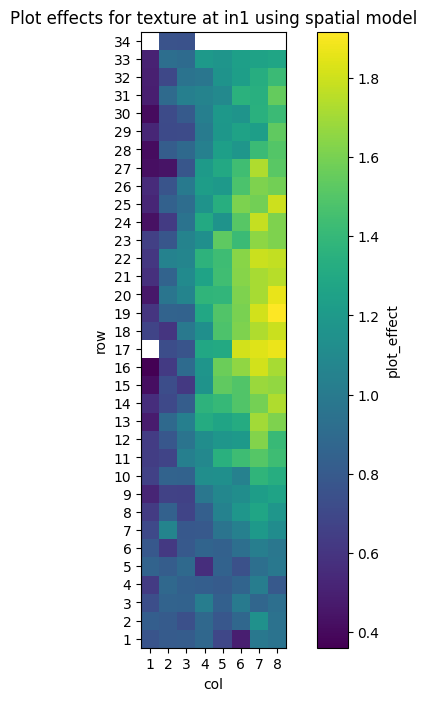

2025-05-26 23:24:25,786 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:25,792 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:25,794 - NtepRsm - INFO - Data preprocessing completed.


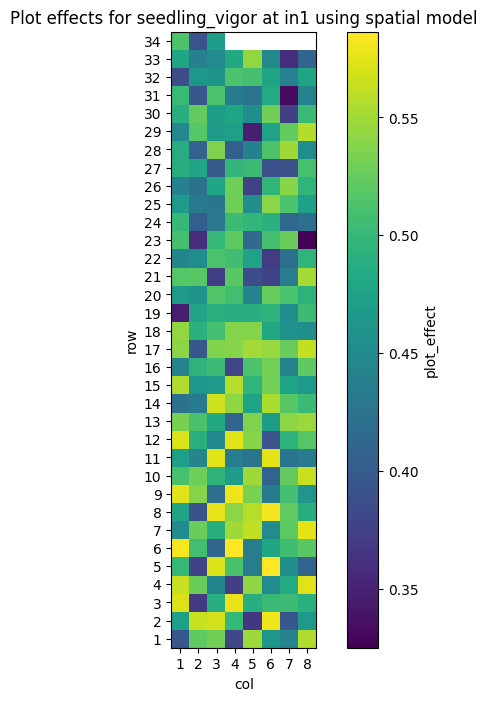

2025-05-26 23:24:26,244 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:26,248 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:269: UserWarning: Column 'plot_code' does not contain continuous codes starting from 1 to 267. Fixing codes using pd.Categorical().codes + 1.
  warnings.warn(
2025-05-26 23:24:26,250 - NtepRsm - INFO - Data preprocessing completed.


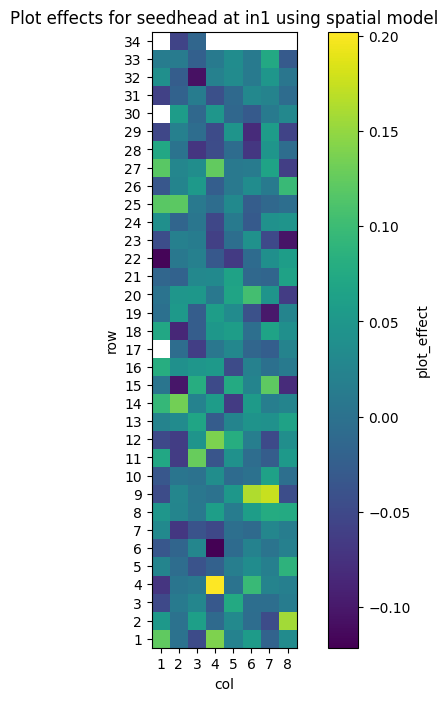

2025-05-26 23:24:26,472 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:26,479 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:26,482 - NtepRsm - INFO - Data preprocessing completed.


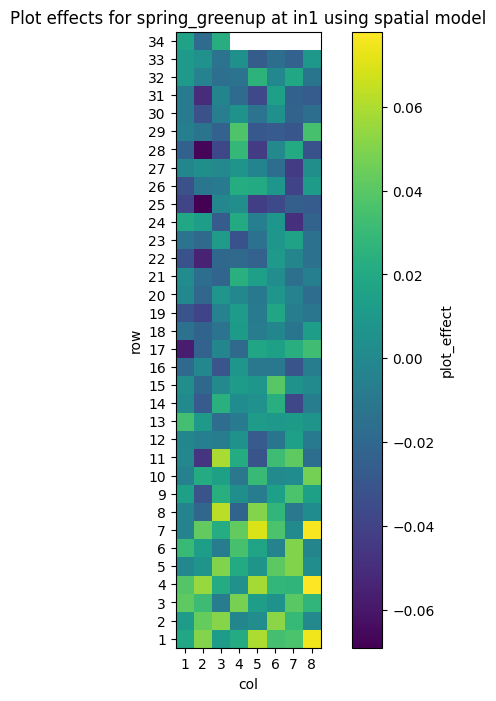

2025-05-26 23:24:26,723 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:26,751 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:26,756 - NtepRsm - INFO - Data preprocessing completed.


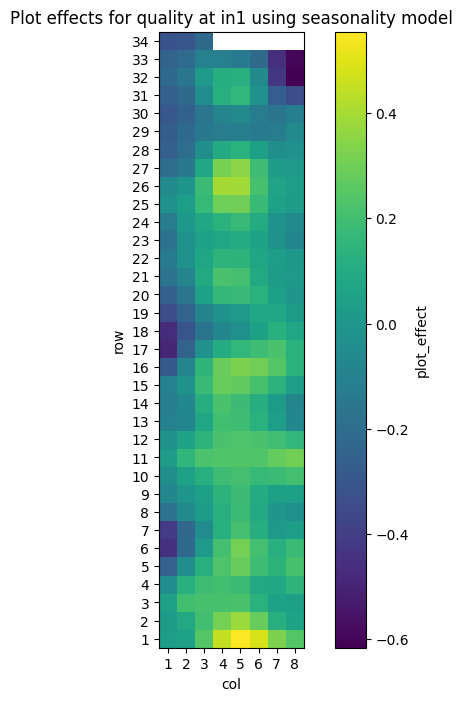

2025-05-26 23:24:34,886 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:34,893 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:34,895 - NtepRsm - INFO - Data preprocessing completed.


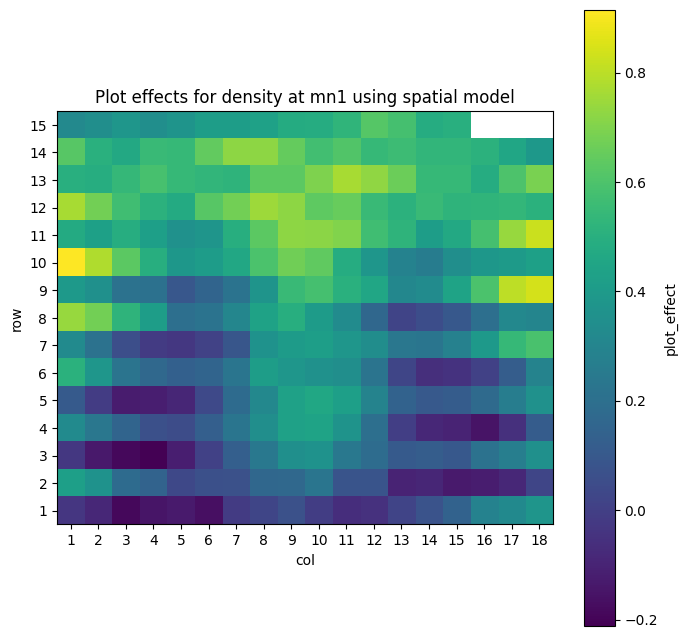

2025-05-26 23:24:35,150 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:35,153 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:35,156 - NtepRsm - INFO - Data preprocessing completed.


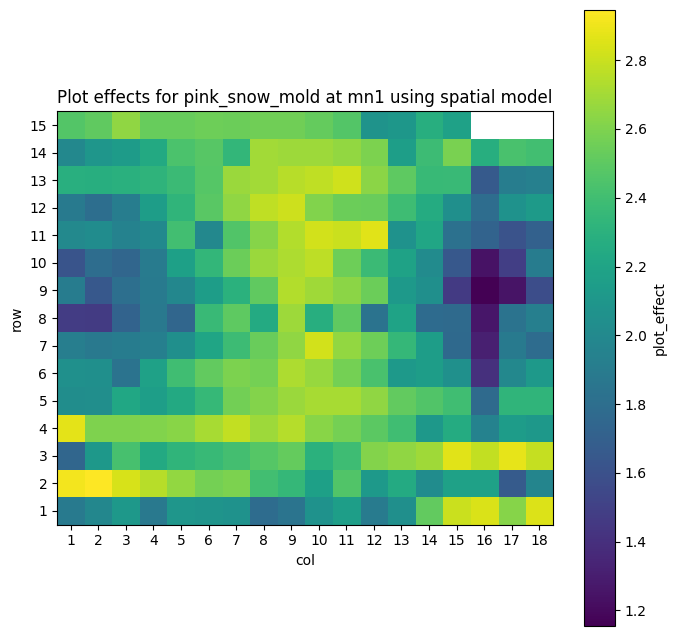

2025-05-26 23:24:35,507 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:35,513 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:35,515 - NtepRsm - INFO - Data preprocessing completed.


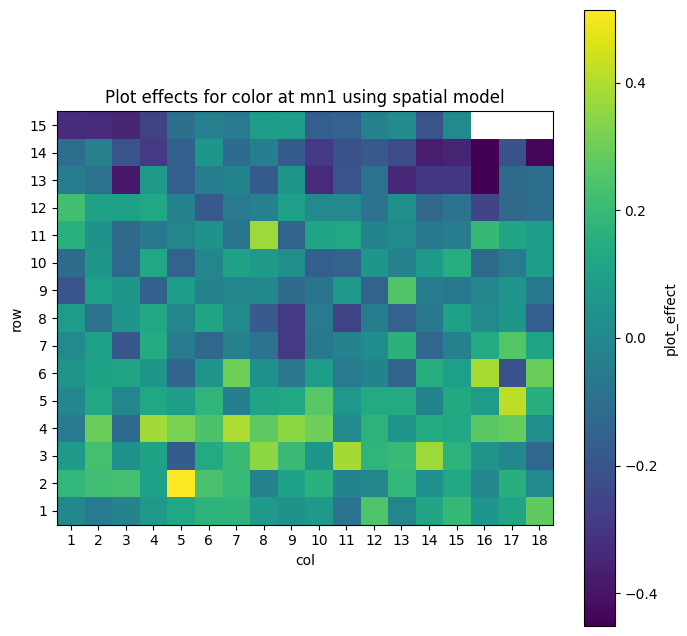

2025-05-26 23:24:35,734 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:35,738 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:35,740 - NtepRsm - INFO - Data preprocessing completed.


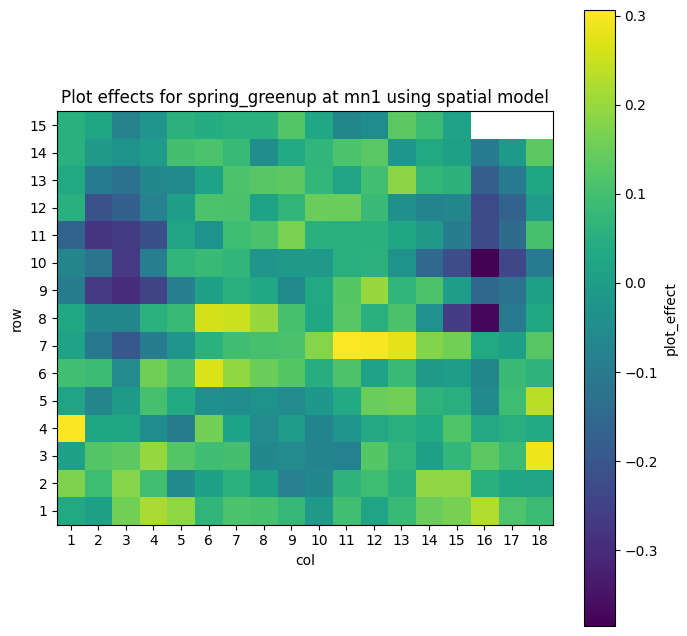

2025-05-26 23:24:35,957 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:35,962 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:35,964 - NtepRsm - INFO - Data preprocessing completed.


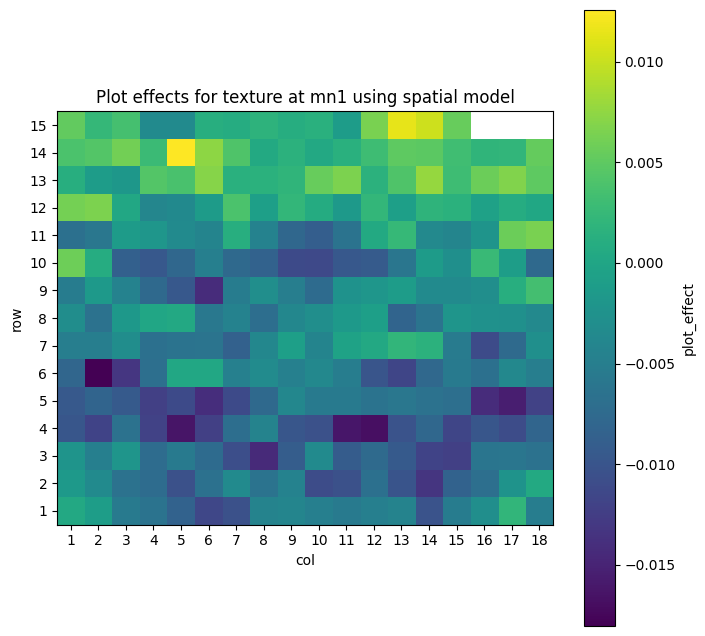

2025-05-26 23:24:36,177 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:36,180 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:36,183 - NtepRsm - INFO - Data preprocessing completed.


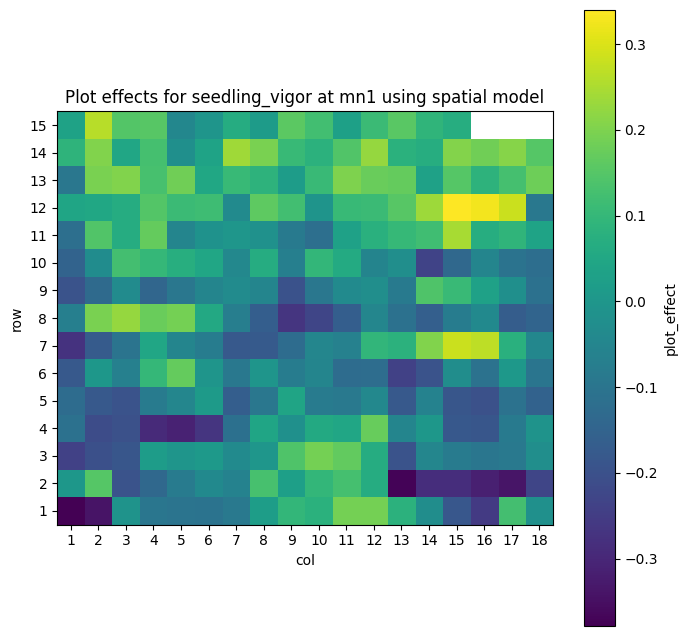

2025-05-26 23:24:36,400 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:36,425 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:36,430 - NtepRsm - INFO - Data preprocessing completed.


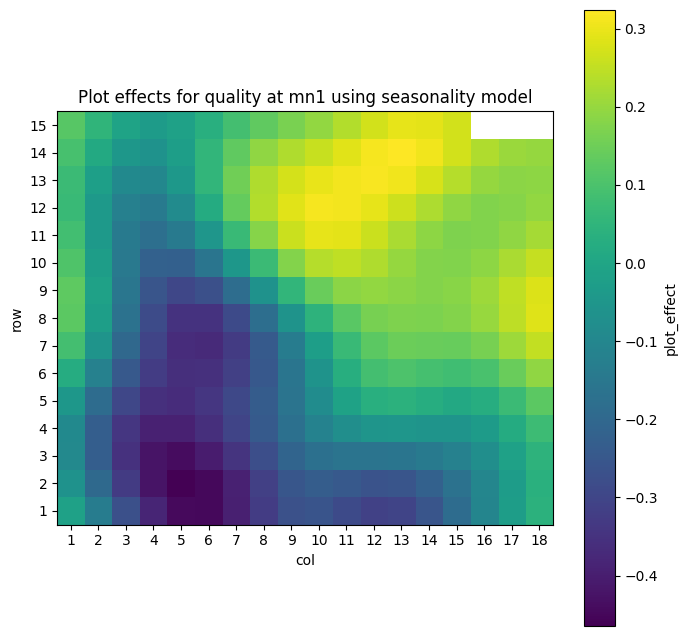

2025-05-26 23:24:42,812 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:42,818 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:42,821 - NtepRsm - INFO - Data preprocessing completed.


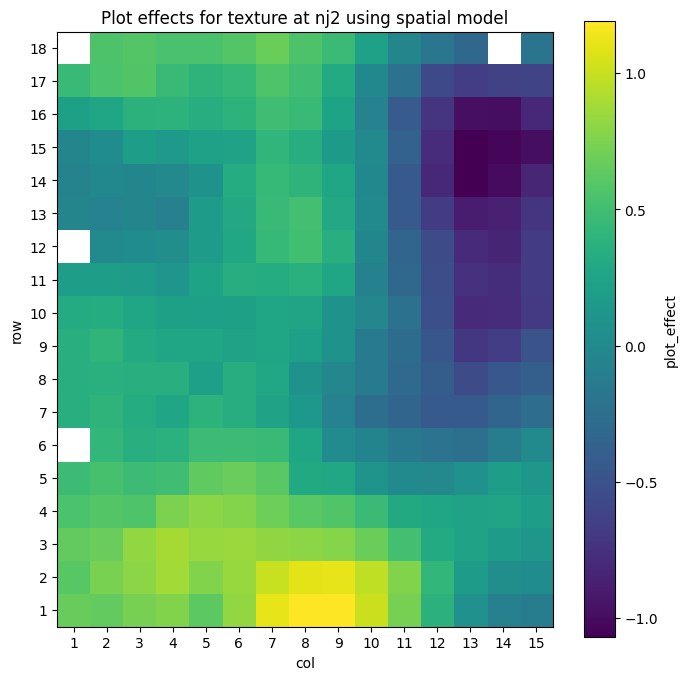

2025-05-26 23:24:43,071 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:43,076 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:43,078 - NtepRsm - INFO - Data preprocessing completed.


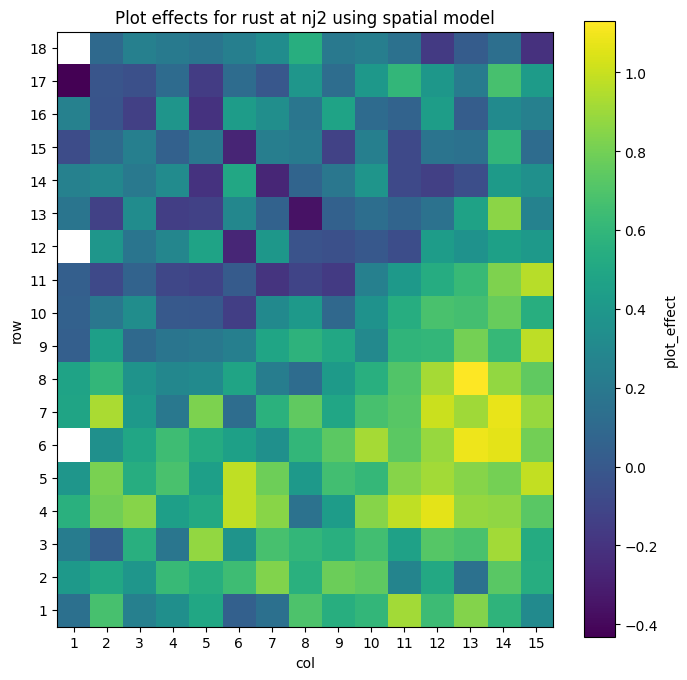

2025-05-26 23:24:43,310 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:43,320 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:43,324 - NtepRsm - INFO - Data preprocessing completed.


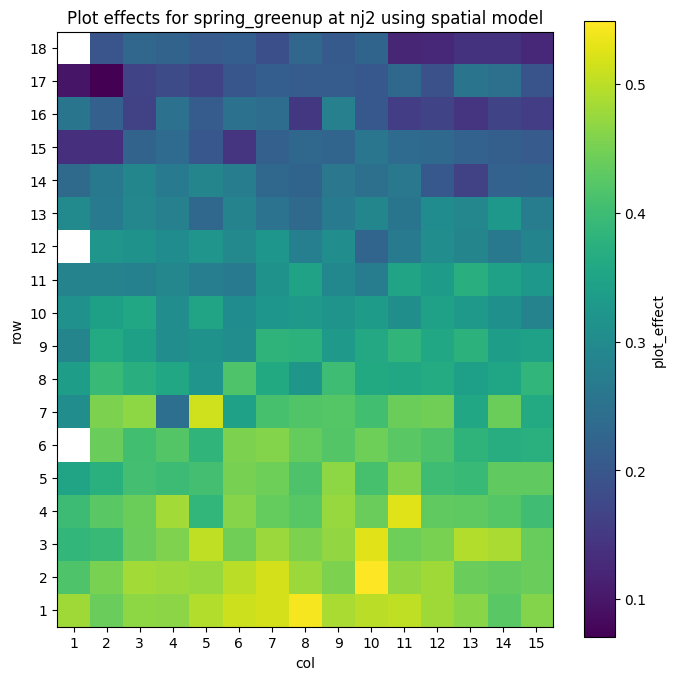

2025-05-26 23:24:43,585 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:43,590 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:43,593 - NtepRsm - INFO - Data preprocessing completed.


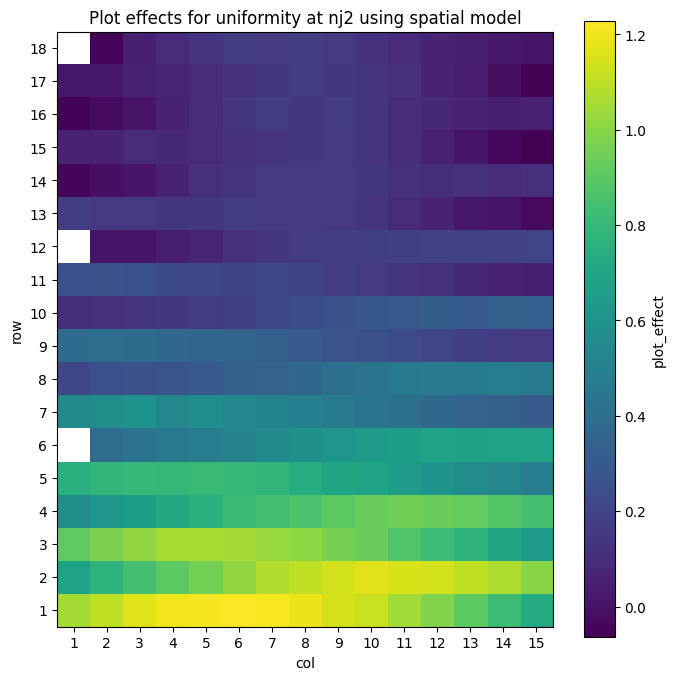

2025-05-26 23:24:43,829 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:43,838 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:43,842 - NtepRsm - INFO - Data preprocessing completed.


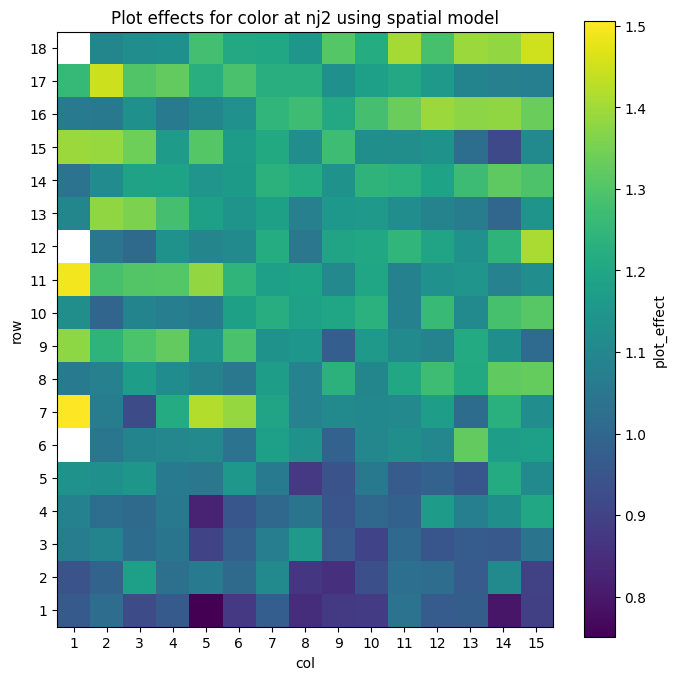

2025-05-26 23:24:44,115 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:44,119 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:44,121 - NtepRsm - INFO - Data preprocessing completed.


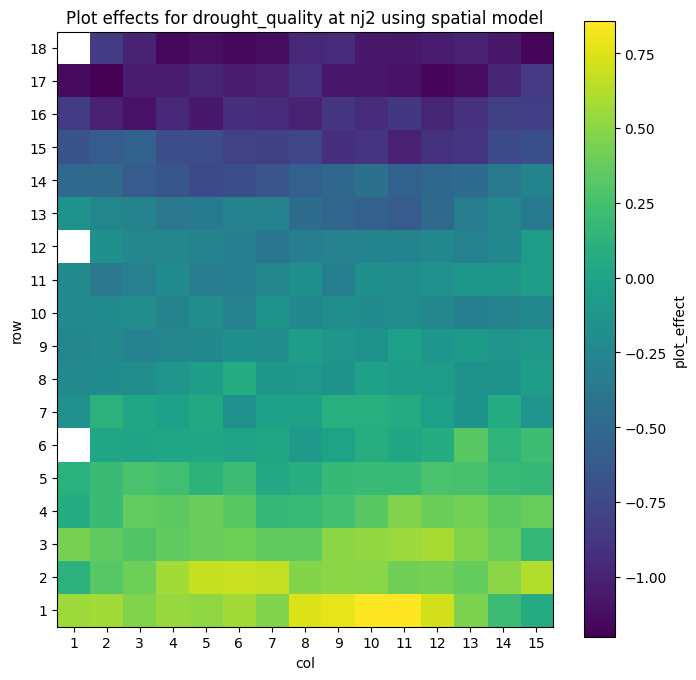

2025-05-26 23:24:44,358 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:44,365 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:44,368 - NtepRsm - INFO - Data preprocessing completed.


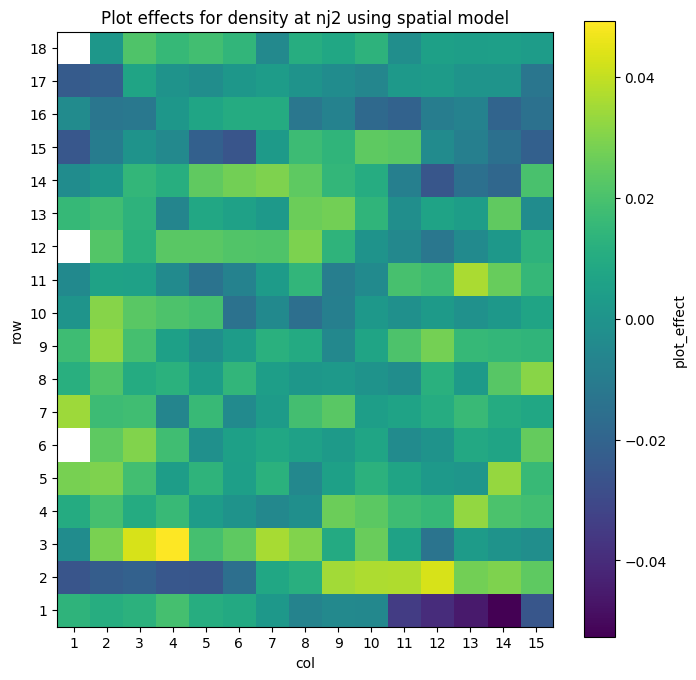

2025-05-26 23:24:44,600 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:44,634 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:44,641 - NtepRsm - INFO - Data preprocessing completed.


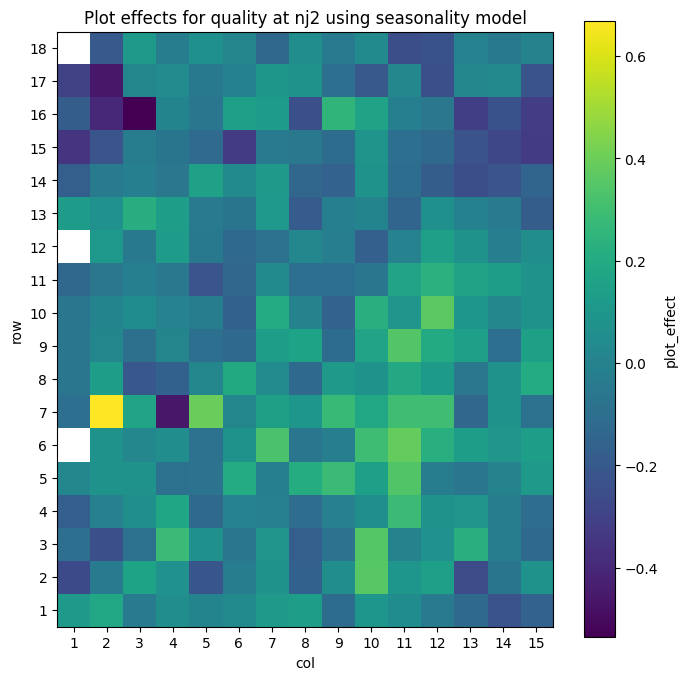

2025-05-26 23:24:54,634 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:54,642 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:54,646 - NtepRsm - INFO - Data preprocessing completed.


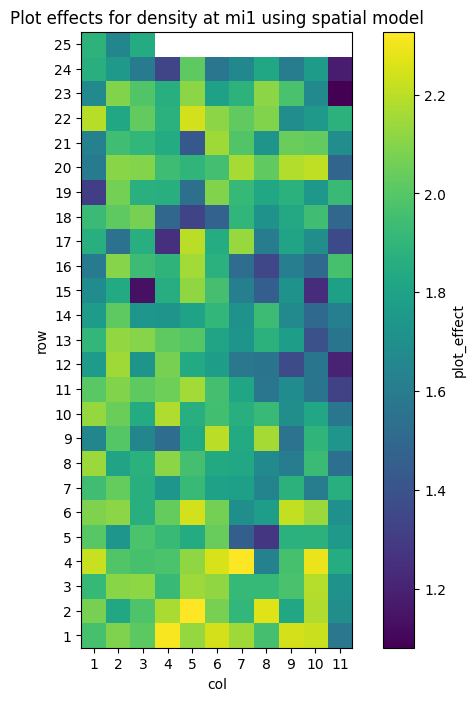

2025-05-26 23:24:55,115 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:55,120 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:55,122 - NtepRsm - INFO - Data preprocessing completed.


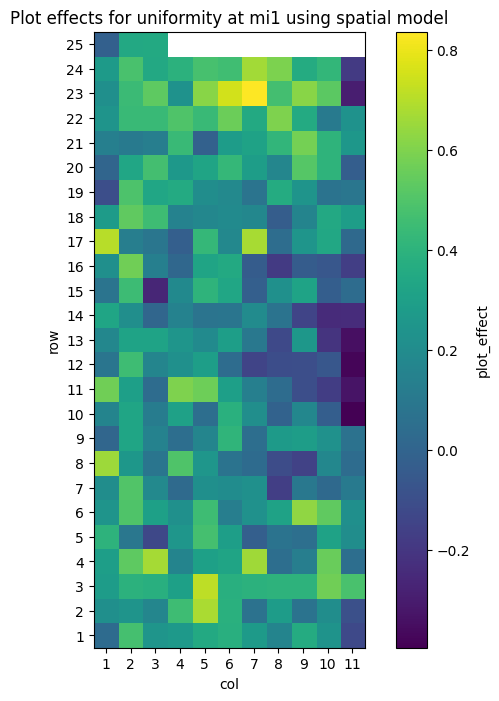

2025-05-26 23:24:55,341 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:55,347 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:55,350 - NtepRsm - INFO - Data preprocessing completed.


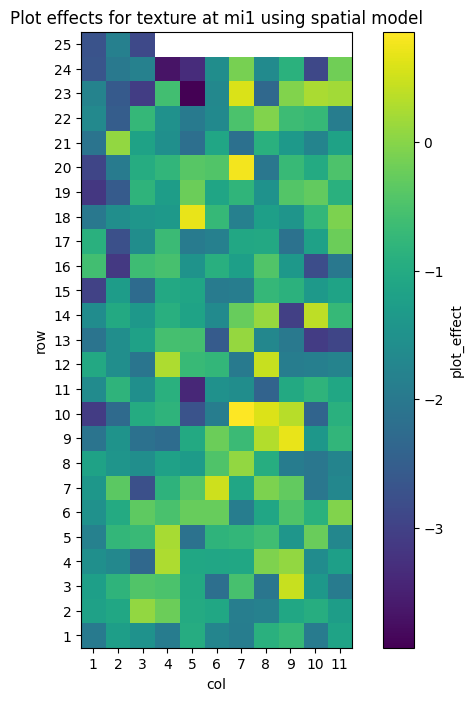

2025-05-26 23:24:55,579 - NtepRsm - DEBUG - Logging is already configured.
2025-05-26 23:24:55,583 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:55,586 - NtepRsm - INFO - Data preprocessing completed.


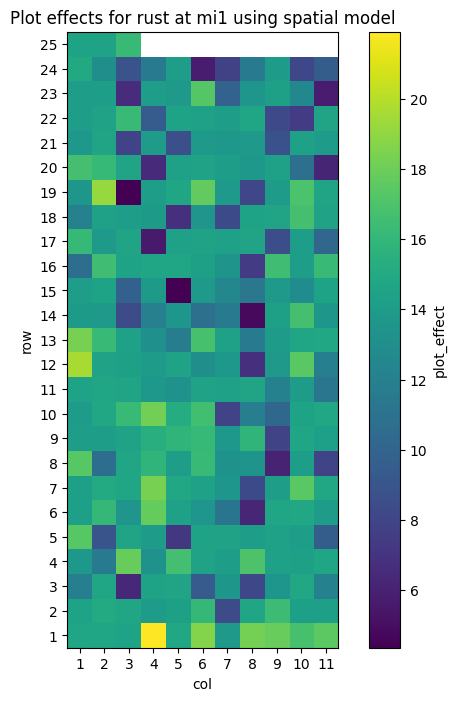

2025-05-26 23:24:55,804 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:55,812 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:55,815 - NtepRsm - INFO - Data preprocessing completed.


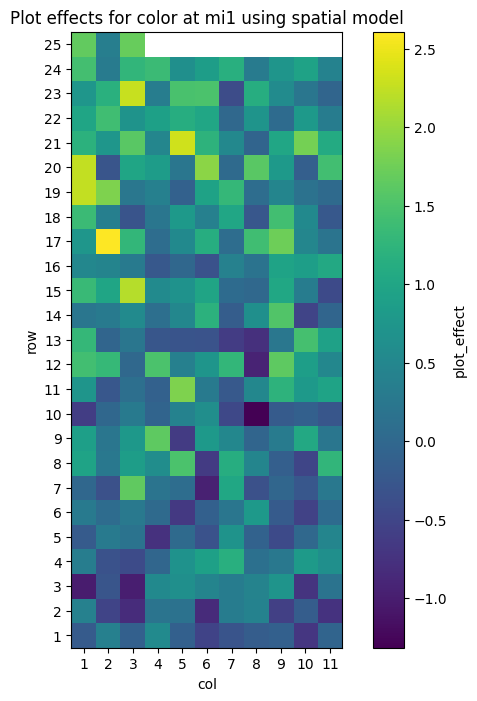

2025-05-26 23:24:56,048 - NtepRsm - DEBUG - Logging is already configured.
/Users/henryqu/Documents/GitHub/nteprsm/nteprsm/utils.py:190: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
2025-05-26 23:24:56,077 - NtepRsm - INFO - Data loaded and processed from provided DataFrame.
2025-05-26 23:24:56,082 - NtepRsm - INFO - Data preprocessing completed.


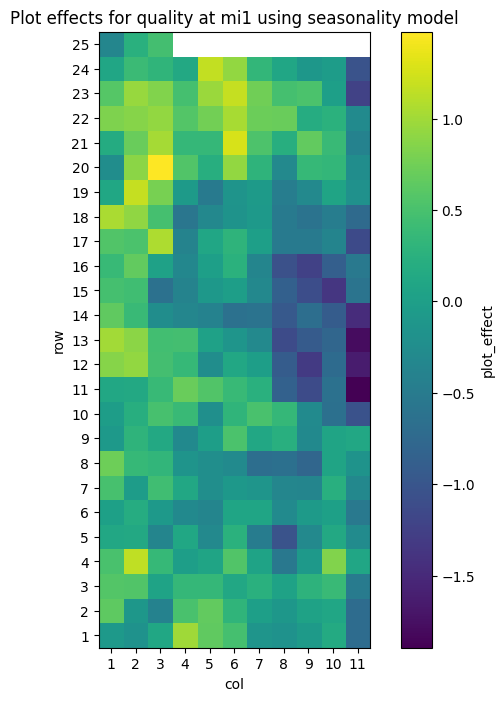

In [ ]:
for loc, model in organized_files.items():
    # create the output directory for each location
    loc_output_dir = output_path / loc
    loc_output_dir.mkdir(parents=True, exist_ok=True)
    entry_profile = pd.DataFrame()
    for model, trait in model.items():
        config_file = glob.glob(str(ROOT_DIR / f"config/*{model}_model.yml"))[0]
        config = utils.load_config(config_file)
        for trait, file in trait.items():
            data_path = DATA_DIR/f'data_ingestion/parsed_data/kb2017/{loc}/{trait}.csv'
            # cretae data handler
            datahandler = utils.DataHandler(filepath=data_path)
            datahandler.load_data(raw_data=pd.read_csv(data_path))
            datahandler.preprocess_data()
            # load fit object from pickle file  
            with open(file, 'rb') as f:
                fit = pickle.load(f)
            if model == "spatial":
                # entry effects
                entry_profile[trait] = fit.stan_variable("entry_effect").mean(axis=0)
                plot_data = extract_plot_effect(datahandler, fit)
                plot_data['entry_name'] = plot_data['entry_code'].map(entry_dict)
                # plot the field layout
                # plot_field_layout(plot_data, trait, loc, model, save_path=loc_output_dir/f"{model}_{trait}_plot_effect.png")
            elif model == "seasonality":
                seasonality_fit_data = extract_time_effect(datahandler, fit)
                # seasonality_fit_data.to_csv(loc_output_dir/f"seasonality_fit_data.csv")
                entry_profile['overall_quality'] = fit.stan_variable("time_effect").mean(axis=0).mean(axis=1)
                seasonality_pred_means = extract_pred_time_effect(fit)
                fig = px.scatter(seasonality_fit_data, x='adj_day_of_year', y='overall_quality', title=f'Seasonality fit for {trait} at {loc}')
                fig.add
                # seasonality_pred_means.to_csv(loc_output_dir/f"seasonality_pred_means.csv")
                seasonality_pred_lb = extract_pred_time_effect(fit, np.quantile, q=0.025)
                # seasonality_pred_lb.to_csv(loc_output_dir/f"seasonality_pred_lb.csv")
                seasonality_pred_ub = extract_pred_time_effect(fit, np.quantile, q=0.975)
                # seasonality_pred_ub.to_csv(loc_output_dir/f"seasonality_pred_ub.csv")
                plot_data = extract_plot_effect(datahandler, fit)
                # plot_data.to_csv(loc_output_dir/f"field_layout.csv")
                plot_field_layout(plot_data, trait, loc, model, save_path=loc_output_dir/f"{model}_{trait}_plot_effect.png")
    entry_profile.index = entry_profile.index + 1    
    entry_profile.index.name = 'entry_code'
    entry_profile.columns = [col.replace('_', ' ').title() for col in entry_profile.columns]
    entry_profile['entry_name'] = entry_profile.index.map(entry_dict)
    # entry_profile.to_csv(loc_output_dir/f"entry_profile.csv")

In [63]:
data

,row,col,Unnamed: 0,plot_code,plot_effect,entry_code
0,1.0,1.0,0.0,1.0,-0.076607,39.0
1,1.0,2.0,1.0,2.0,-0.170469,12.0
2,1.0,3.0,2.0,3.0,0.108206,52.0
3,1.0,4.0,3.0,4.0,0.990192,84.0
4,1.0,5.0,4.0,5.0,0.652831,25.0
...,...,...,...,...,...,...
270,25.0,7.0,NaN,filler entry,0.536627,NaN
271,25.0,8.0,NaN,filler entry,0.217424,NaN
272,25.0,9.0,NaN,filler entry,0.045099,NaN
273,25.0,10.0,NaN,filler entry,-0.282941,NaN


In [57]:
# for seasonality_plot_data, fill missing values with mean
plot_data_files = glob.glob(f"{output_path}/*/field_layout.csv")
plot_data_files

['/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/nj2/field_layout.csv',
 '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/ut1/field_layout.csv',
 '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/in1/field_layout.csv',
 '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/mn1/field_layout.csv',
 '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/ok1/field_layout.csv',
 '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/nc1/field_layout.csv',
 '/Users/henryqu/Library/CloudStorage/GoogleDrive-yqu@oxbridge-econ.com/My Drive/NTEP/model_output/kb2017/mi1/field_layout.csv']

nj2


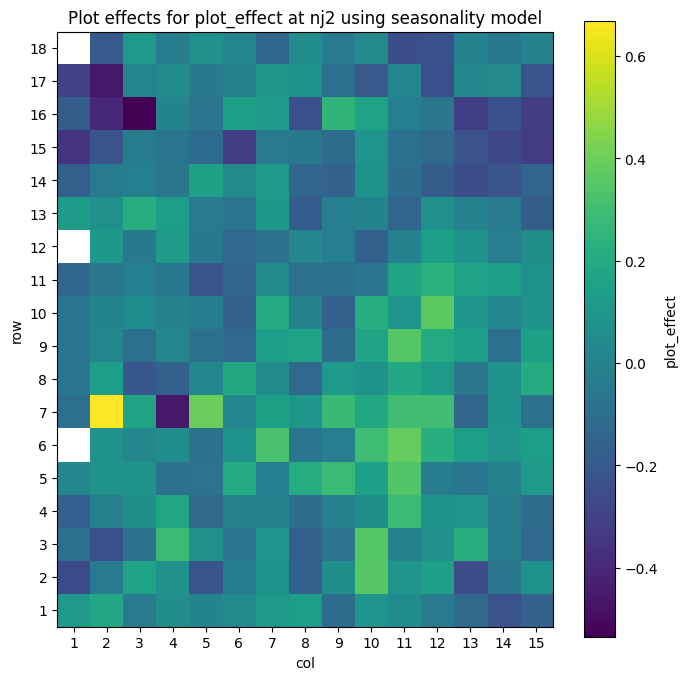

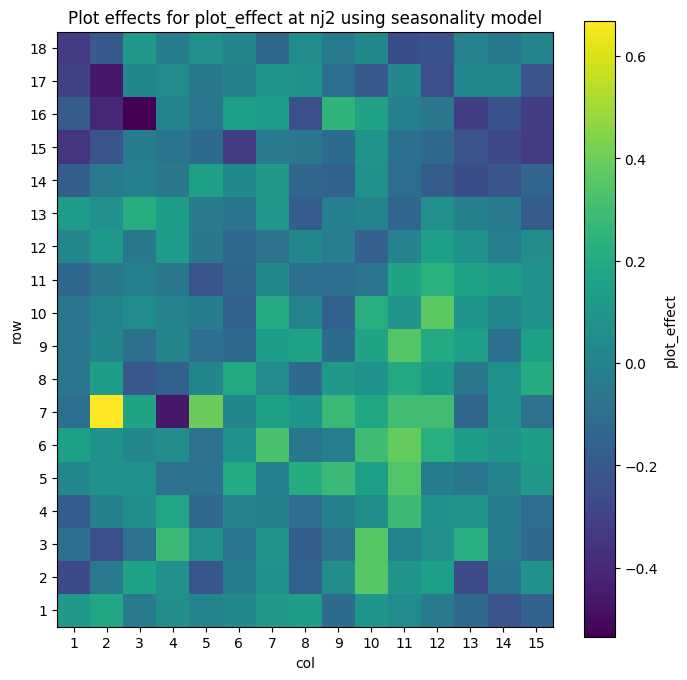

ut1


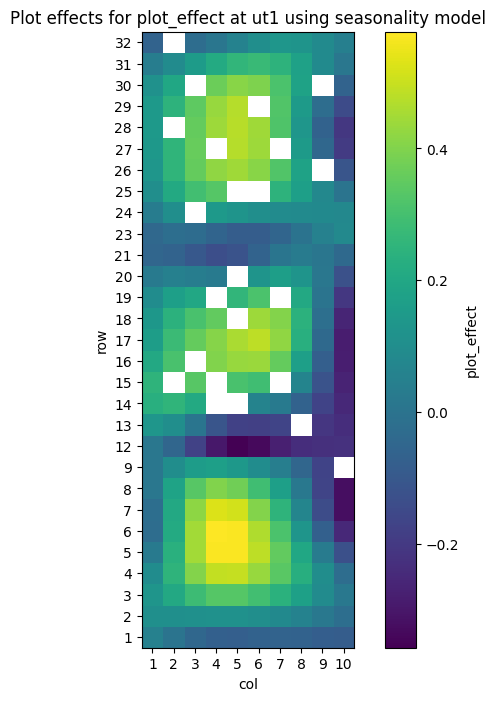

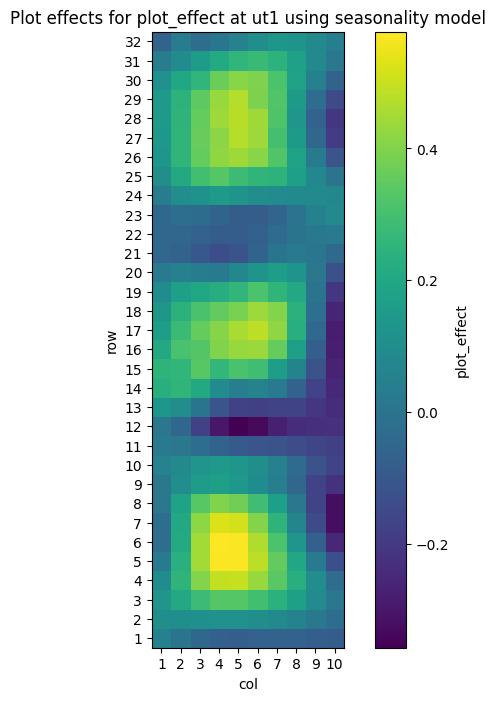

in1


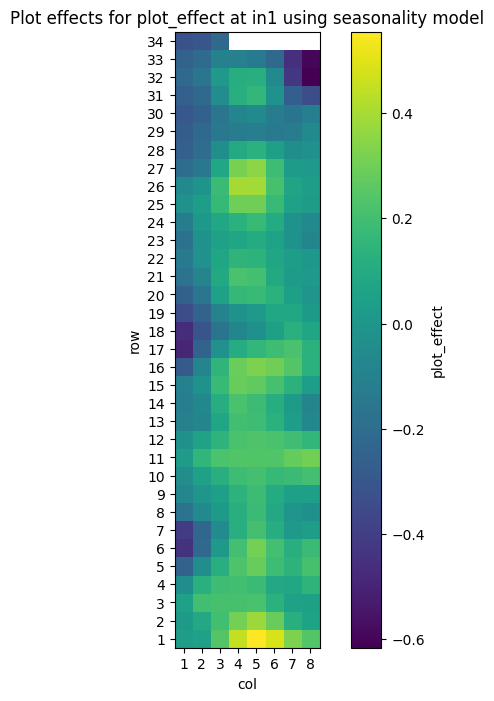

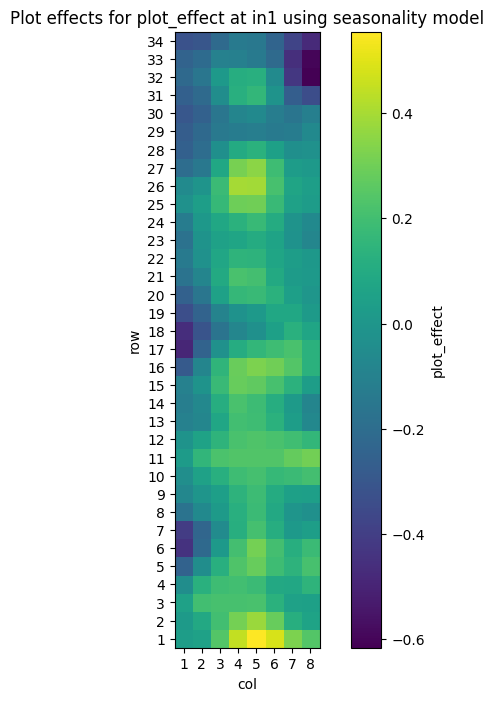

mn1


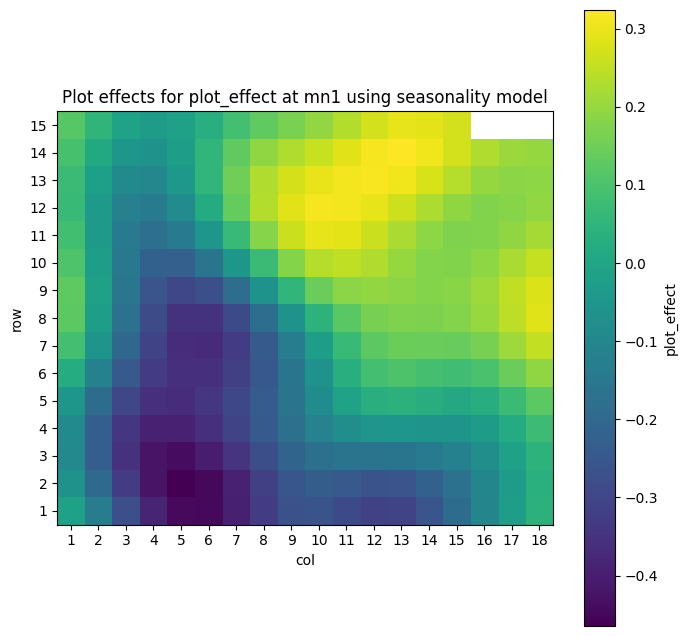

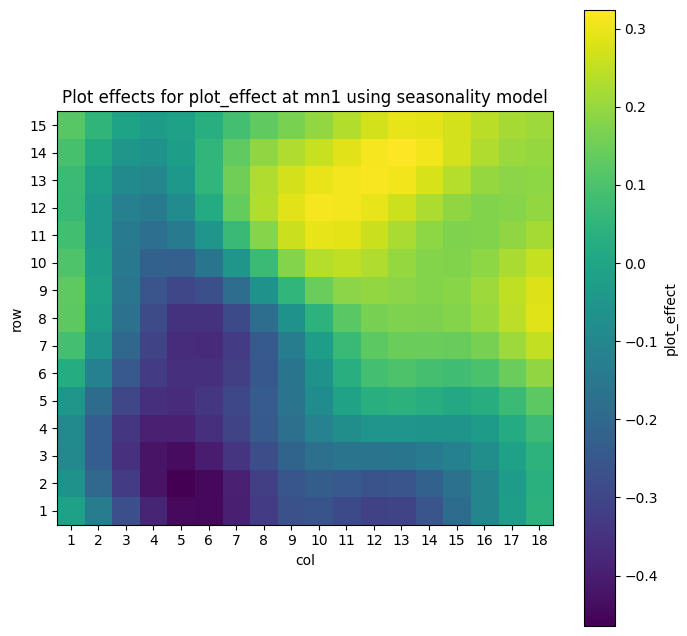

ok1


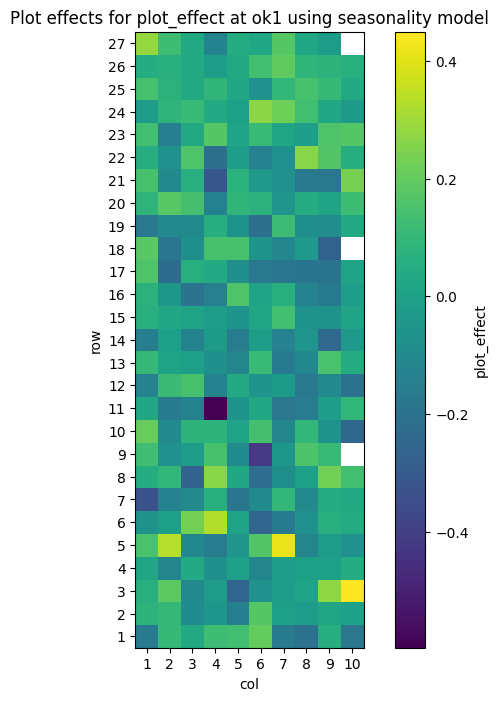

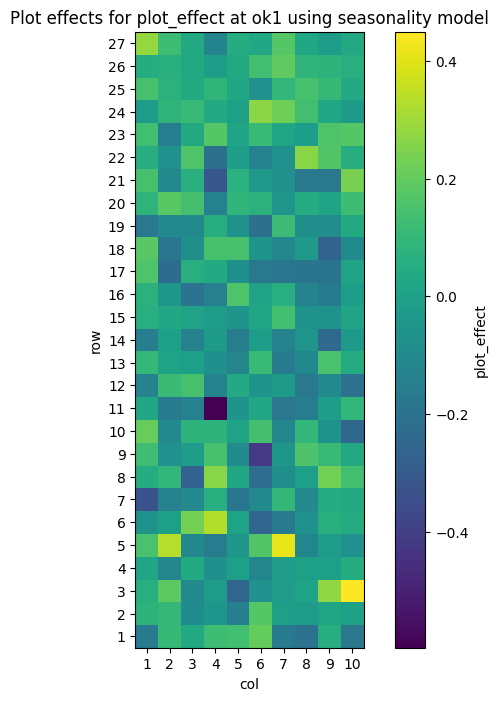

nc1


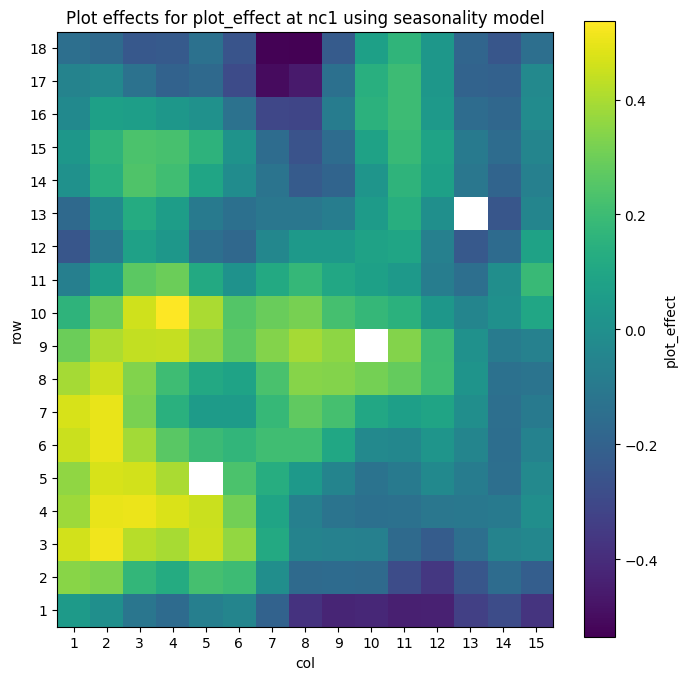

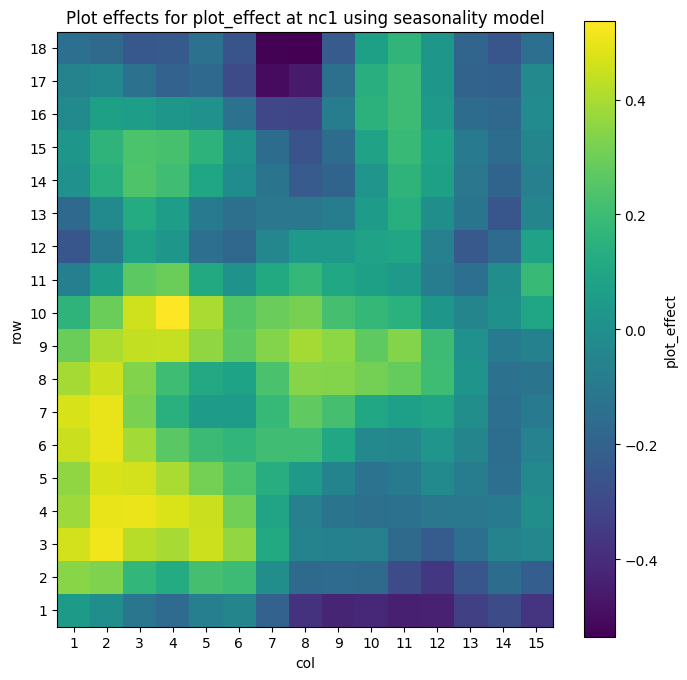

mi1


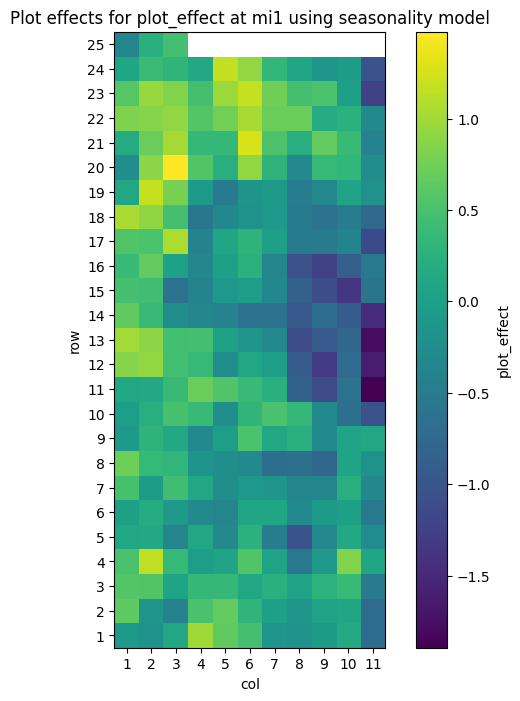

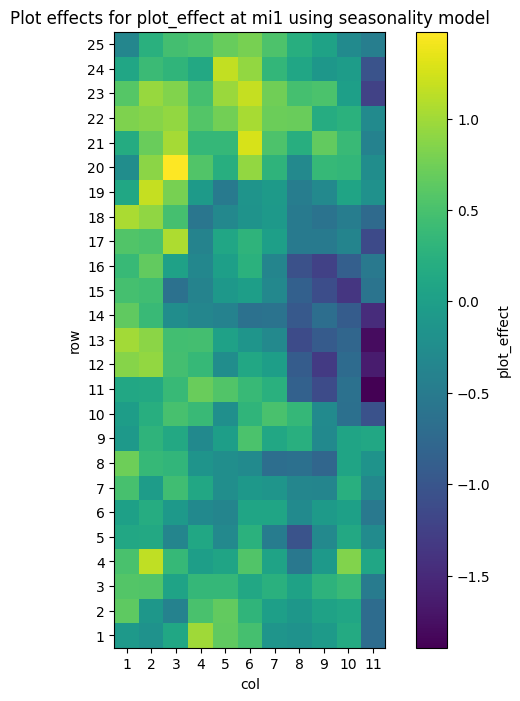

In [64]:
for file in plot_data_files:
    loc = file.split("/")[-2]
    print(loc)
    data = pd.read_csv(file)
    plot_field_layout(data, "plot_effect", loc, "seasonality")
    # Ensure all combinations of row and col exist, fill missing plot_effect with mean
    rows = np.arange(1, data['row'].max() + 1)
    cols = np.arange(1, data['col'].max() + 1)
    full_index = pd.MultiIndex.from_product([rows, cols], names=['row', 'col'])
    data = data.set_index(['row', 'col']).reindex(full_index).reset_index()
    # Fill missing plot_effect with mean of 8 neighbors (Moore neighborhood)
    def neighbor_mean(row, col, df):
        neighbors = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                nrow, ncol = row + dr, col + dc
                val = df.loc[(df['row'] == nrow) & (df['col'] == ncol), 'plot_effect']
                if not val.empty and not np.isnan(val.values[0]):
                    neighbors.append(val.values[0])
        return np.mean(neighbors) if neighbors else np.nan

    missing = data['plot_effect'].isna()
    for idx in data[missing].index:
        row, col = data.loc[idx, ['row', 'col']]
        data.at[idx, 'plot_effect'] = neighbor_mean(row, col, data)
    # If still missing (e.g., all neighbors missing), fill with overall mean
    mean_effect = data['plot_effect'].mean()
    data['plot_effect'] = data['plot_effect'].fillna(mean_effect)
    data['plot_code'] = data['plot_code'].fillna('filler entry')
    data.drop(columns=['Unnamed: 0'], inplace=True)
    data.to_csv(output_path/f"{loc}/field_layout_filled.csv")
    plot_field_layout(data, "plot_effect", loc, "seasonality", save_path=output_path/f"{loc}/field_layout_filled.png")

In [252]:
import os
import pickle

os.makedirs(output_path.parent, exist_ok=True)

with open(output_path, 'wb') as file:
    pickle.dump(fit, file)